### Zadanie 1
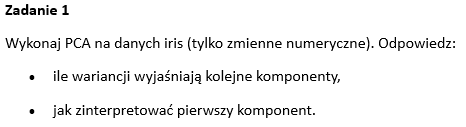

In [2]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================
# 1. Wczytanie danych
# =========================
iris = load_iris()

# Tworzymy DataFrame tylko ze zmiennych numerycznych
df = pd.DataFrame(iris.data, columns=iris.feature_names)

print("Pierwsze 5 wierszy danych:")
print(df.head())
print()

Pierwsze 5 wierszy danych:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2



In [3]:
# =========================
# 2. Standaryzacja danych
# =========================
# PCA jest wrażliwe na skalę zmiennych, więc standardyzujemy dane
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [4]:
# =========================
# 3. PCA
# =========================
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [5]:
# =========================
# 4. Wariancja wyjaśniana
# =========================
explained_variance_ratio = pca.explained_variance_ratio_
explained_variance_percent = explained_variance_ratio * 100
cumulative_variance_percent = explained_variance_percent.cumsum()

results = pd.DataFrame({
    "Komponent": [f"PC{i+1}" for i in range(len(explained_variance_ratio))],
    "Wariancja wyjaśniana [%]": explained_variance_percent,
    "Skumulowana wariancja [%]": cumulative_variance_percent
})

print("Wariancja wyjaśniana przez kolejne komponenty:")
print(results.round(2))
print()

Wariancja wyjaśniana przez kolejne komponenty:
  Komponent  Wariancja wyjaśniana [%]  Skumulowana wariancja [%]
0       PC1                     72.96                      72.96
1       PC2                     22.85                      95.81
2       PC3                      3.67                      99.48
3       PC4                      0.52                     100.00



In [6]:
# =========================
# 5. Ładunki komponentów
# =========================
# Współczynniki mówią, jak silnie każda cecha wpływa na dany komponent
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=df.columns
)

print("Ładunki komponentów:")
print(loadings.round(4))
print()

Ładunki komponentów:
                      PC1     PC2     PC3     PC4
sepal length (cm)  0.5211  0.3774  0.7196 -0.2613
sepal width (cm)  -0.2693  0.9233 -0.2444  0.1235
petal length (cm)  0.5804  0.0245 -0.1421  0.8014
petal width (cm)   0.5649  0.0669 -0.6343 -0.5236



In [7]:
# =========================
# 6. Interpretacja pierwszego komponentu
# =========================
print("Ładunki dla pierwszego komponentu (PC1):")
print(loadings["PC1"].sort_values(key=abs, ascending=False).round(4))

Ładunki dla pierwszego komponentu (PC1):
petal length (cm)    0.5804
petal width (cm)     0.5649
sepal length (cm)    0.5211
sepal width (cm)    -0.2693
Name: PC1, dtype: float64


### Zadanie 2

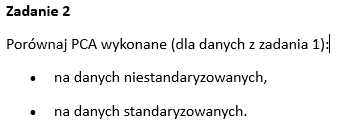

In [8]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================
# 1. Dane
# =========================
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [9]:
# =========================
# 2. PCA bez standaryzacji
# =========================
pca_raw = PCA()
X_pca_raw = pca_raw.fit_transform(df)

raw_variance = pca_raw.explained_variance_ratio_ * 100

raw_results = pd.DataFrame({
    "Komponent": [f"PC{i+1}" for i in range(len(raw_variance))],
    "Wariancja [%]": raw_variance,
    "Skumulowana [%]": raw_variance.cumsum()
})

In [10]:
# =========================
# 3. PCA ze standaryzacją
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

pca_scaled = PCA()
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

scaled_variance = pca_scaled.explained_variance_ratio_ * 100

scaled_results = pd.DataFrame({
    "Komponent": [f"PC{i+1}" for i in range(len(scaled_variance))],
    "Wariancja [%]": scaled_variance,
    "Skumulowana [%]": scaled_variance.cumsum()
})

In [11]:
# =========================
# 4. Ładunki (do interpretacji)
# =========================
loadings_raw = pd.DataFrame(
    pca_raw.components_.T,
    columns=[f"PC{i+1}" for i in range(4)],
    index=df.columns
)

loadings_scaled = pd.DataFrame(
    pca_scaled.components_.T,
    columns=[f"PC{i+1}" for i in range(4)],
    index=df.columns
)

In [12]:
# =========================
# 5. Wyniki
# =========================
print("=== PCA bez standaryzacji ===")
print(raw_results.round(2))
print("\nŁadunki PC1:")
print(loadings_raw["PC1"].sort_values(key=abs, ascending=False).round(4))

print("\n\n=== PCA ze standaryzacją ===")
print(scaled_results.round(2))
print("\nŁadunki PC1:")
print(loadings_scaled["PC1"].sort_values(key=abs, ascending=False).round(4))

=== PCA bez standaryzacji ===
  Komponent  Wariancja [%]  Skumulowana [%]
0       PC1          92.46            92.46
1       PC2           5.31            97.77
2       PC3           1.71            99.48
3       PC4           0.52           100.00

Ładunki PC1:
petal length (cm)    0.8567
sepal length (cm)    0.3614
petal width (cm)     0.3583
sepal width (cm)    -0.0845
Name: PC1, dtype: float64


=== PCA ze standaryzacją ===
  Komponent  Wariancja [%]  Skumulowana [%]
0       PC1          72.96            72.96
1       PC2          22.85            95.81
2       PC3           3.67            99.48
3       PC4           0.52           100.00

Ładunki PC1:
petal length (cm)    0.5804
petal width (cm)     0.5649
sepal length (cm)    0.5211
sepal width (cm)    -0.2693
Name: PC1, dtype: float64


**Różnice w wariancji**
- Bez standaryzacji:
    - pierwszy komponent wyjaśnia ponad 90% wariancji
    - PCA jest zdominowane przez jedną zmienną (skalę danych)
- Ze standaryzacją:
    - pierwszy komponent wyjaśnia ~73%
    - drugi ~23%
    - struktura danych jest lepiej rozłożona

PCA na danych niestandaryzowanych jest zdominowane przez zmienne o największej wariancji, przez co pierwszy komponent wyjaśnia ponad 90% wariancji i odzwierciedla głównie zmienność tych zmiennych (np. długości i szerokości płatków). Po standaryzacji wszystkie zmienne mają równy wpływ, co prowadzi do bardziej zrównoważonego rozkładu wariancji (ok. 73% i 23% dla dwóch pierwszych komponentów) oraz umożliwia interpretację pierwszego komponentu jako ogólnego rozmiaru kwiatu.

### Zadanie 3

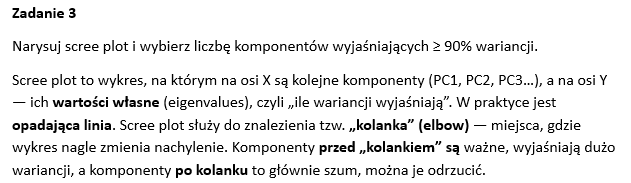

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================
# 1. Dane + standaryzacja
# =========================
iris = load_iris()
X = iris.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# =========================
# 2. PCA
# =========================
pca = PCA()
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [15]:
# =========================
# 3. Wariancja i eigenvalues
# =========================
explained_variance = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_

cumulative_variance = np.cumsum(explained_variance)

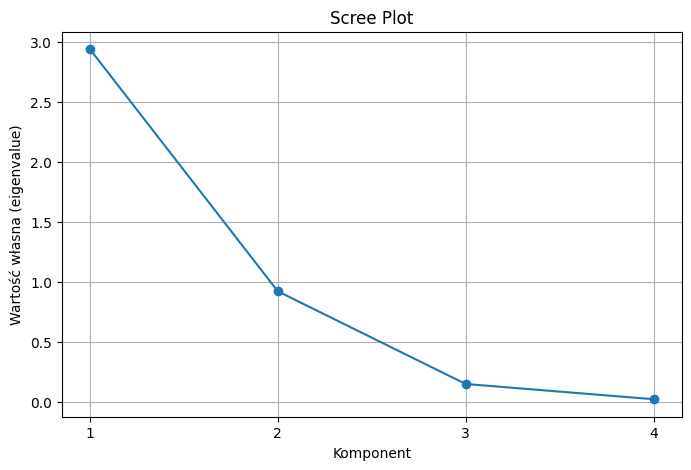

In [16]:
# =========================
# 4. Scree plot
# =========================
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o')
plt.title("Scree Plot")
plt.xlabel("Komponent")
plt.ylabel("Wartość własna (eigenvalue)")

plt.xticks(range(1, len(eigenvalues) + 1))
plt.grid(True)

plt.show()

In [17]:
# =========================
# 5. Wariancja skumulowana
# =========================
print("Wariancja skumulowana:")
for i, val in enumerate(cumulative_variance):
    print(f"PC{i+1}: {val*100:.2f}%")

Wariancja skumulowana:
PC1: 72.96%
PC2: 95.81%
PC3: 99.48%
PC4: 100.00%


In [18]:
# =========================
# 6. Minimalna liczba komponentów >= 90%
# =========================
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"\nLiczba komponentów dla >=90% wariancji: {n_components_90}")


Liczba komponentów dla >=90% wariancji: 2


Na podstawie scree plotu można zaobserwować wyraźny „łokieć” przy drugim komponencie. Pierwszy komponent wyjaśnia około 73% wariancji, drugi około 23%, co łącznie daje około 96% wariancji. Kolejne komponenty wnoszą już bardzo niewielki wkład. W związku z tym optymalnym wyborem jest redukcja wymiarowości do 2 komponentów, które wyjaśniają ponad 90% wariancji danych.

### Zadanie 4
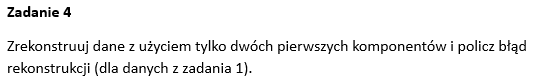

In [19]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# =========================
# 1. Wczytanie danych
# =========================
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)

print("Oryginalne dane:")
print(df.head())
print()

Oryginalne dane:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2



In [20]:
# =========================
# 2. Standaryzacja
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
# =========================
# 3. PCA do 2 komponentów
# =========================
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

print("Kształt po redukcji do 2 komponentów:", X_pca_2.shape)
print()

Kształt po redukcji do 2 komponentów: (150, 2)



In [22]:
# =========================
# 4. Rekonstrukcja danych
# =========================
# inverse_transform odtwarza dane w przestrzeni standaryzowanej
X_reconstructed_scaled = pca_2.inverse_transform(X_pca_2)

# Powrót do oryginalnej skali
X_reconstructed = scaler.inverse_transform(X_reconstructed_scaled)

df_reconstructed = pd.DataFrame(X_reconstructed, columns=feature_names)

print("Zrekonstruowane dane:")
print(df_reconstructed.head())
print()

Zrekonstruowane dane:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           5.018949          3.514854           1.466013          0.251922
1           4.738463          3.030433           1.603913          0.272074
2           4.720130          3.196830           1.328961          0.167414
3           4.668436          3.086770           1.384170          0.182247
4           5.017093          3.596402           1.345411          0.206706



In [23]:
# =========================
# 5. Błąd rekonstrukcji
# =========================
# Błąd w skali oryginalnej
mse_original = mean_squared_error(X, X_reconstructed)
rmse_original = np.sqrt(mse_original)

# Błąd w przestrzeni standaryzowanej
mse_scaled = mean_squared_error(X_scaled, X_reconstructed_scaled)
rmse_scaled = np.sqrt(mse_scaled)

print(f"MSE rekonstrukcji (skala oryginalna): {mse_original:.6f}")
print(f"RMSE rekonstrukcji (skala oryginalna): {rmse_original:.6f}")
print()

print(f"MSE rekonstrukcji (skala standaryzowana): {mse_scaled:.6f}")
print(f"RMSE rekonstrukcji (skala standaryzowana): {rmse_scaled:.6f}")
print()

MSE rekonstrukcji (skala oryginalna): 0.035537
RMSE rekonstrukcji (skala oryginalna): 0.188513

MSE rekonstrukcji (skala standaryzowana): 0.041868
RMSE rekonstrukcji (skala standaryzowana): 0.204617



In [24]:
# =========================
# 6. Błąd dla każdej cechy osobno
# =========================
feature_mse = {}
for i, col in enumerate(feature_names):
    feature_mse[col] = mean_squared_error(X[:, i], X_reconstructed[:, i])

feature_mse_df = pd.DataFrame({
    "Cecha": list(feature_mse.keys()),
    "MSE": list(feature_mse.values()),
    "RMSE": [np.sqrt(v) for v in feature_mse.values()]
})

print("Błąd rekonstrukcji dla poszczególnych cech:")
print(feature_mse_df.round(6))

Błąd rekonstrukcji dla poszczególnych cech:
               Cecha       MSE      RMSE
0  sepal length (cm)  0.052720  0.229608
1   sepal width (cm)  0.001714  0.041396
2  petal length (cm)  0.050364  0.224419
3   petal width (cm)  0.037352  0.193266


Dane zostały zrekonstruowane z użyciem dwóch pierwszych komponentów głównych. W tym celu najpierw wykonano PCA na danych standaryzowanych, następnie pozostawiono tylko dwa pierwsze komponenty i zastosowano transformację odwrotną. Otrzymane dane porównano z danymi oryginalnymi, obliczając błąd rekonstrukcji za pomocą miary MSE oraz RMSE. Ponieważ dwa pierwsze komponenty wyjaśniają około 96% wariancji, błąd rekonstrukcji jest niewielki, co oznacza, że redukcja wymiarowości do 2 komponentów zachowuje większość informacji zawartej w danych.

### Zadanie 5
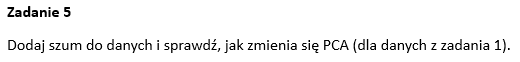

In [25]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================
# 1. Dane
# =========================
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

In [26]:
# =========================
# 2. Standaryzacja
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
# =========================
# 3. PCA (bez szumu)
# =========================
pca_clean = PCA()
pca_clean.fit(X_scaled)

var_clean = pca_clean.explained_variance_ratio_

In [28]:
# =========================
# 4. Dodanie szumu
# =========================
np.random.seed(42)

noise_level = 0.5  # możesz zmieniać: 0.1, 0.5, 1.0
noise = np.random.normal(0, noise_level, X.shape)

X_noisy = X + noise

# Standaryzacja ponownie (ważne!)
X_noisy_scaled = scaler.fit_transform(X_noisy)

In [29]:
# =========================
# 5. PCA (ze szumem)
# =========================
pca_noisy = PCA()
pca_noisy.fit(X_noisy_scaled)

var_noisy = pca_noisy.explained_variance_ratio_

In [30]:
# =========================
# 6. Porównanie
# =========================
comparison = pd.DataFrame({
    "Komponent": [f"PC{i+1}" for i in range(len(var_clean))],
    "Bez szumu [%]": var_clean * 100,
    "Z szumem [%]": var_noisy * 100,
})

comparison["Różnica"] = comparison["Z szumem [%]"] - comparison["Bez szumu [%]"]

print(comparison.round(2))

  Komponent  Bez szumu [%]  Z szumem [%]  Różnica
0       PC1          72.96         61.84   -11.12
1       PC2          22.85         23.85     1.00
2       PC3           3.67          9.40     5.73
3       PC4           0.52          4.92     4.40


In [31]:
# =========================
# 7. Ładunki PC1
# =========================
loadings_clean = pd.DataFrame(
    pca_clean.components_.T,
    columns=[f"PC{i+1}" for i in range(4)],
    index=feature_names
)

loadings_noisy = pd.DataFrame(
    pca_noisy.components_.T,
    columns=[f"PC{i+1}" for i in range(4)],
    index=feature_names
)

print("\nPC1 bez szumu:")
print(loadings_clean["PC1"].sort_values(key=abs, ascending=False).round(4))

print("\nPC1 ze szumem:")
print(loadings_noisy["PC1"].sort_values(key=abs, ascending=False).round(4))


PC1 bez szumu:
petal length (cm)    0.5804
petal width (cm)     0.5649
sepal length (cm)    0.5211
sepal width (cm)    -0.2693
Name: PC1, dtype: float64

PC1 ze szumem:
petal length (cm)    0.5937
petal width (cm)     0.5589
sepal length (cm)    0.5259
sepal width (cm)    -0.2419
Name: PC1, dtype: float64


Po dodaniu szumu do danych zaobserwowano spadek wariancji wyjaśnianej przez pierwszy komponent oraz bardziej równomierny rozkład wariancji pomiędzy komponentami. Wynika to z faktu, że szum wprowadza losową zmienność we wszystkich kierunkach, co osłabia dominujące struktury danych. W konsekwencji zwiększa się liczba komponentów potrzebnych do wyjaśnienia tego samego poziomu wariancji, a interpretacja komponentów staje się mniej jednoznaczna. PCA nie odróżnia sygnału od szumu, ponieważ opiera się wyłącznie na maksymalizacji wariancji.

### Zadanie 6
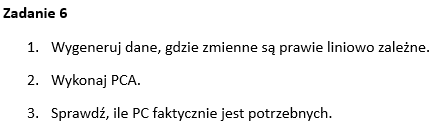

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =========================
# 1. Generowanie danych
# =========================
np.random.seed(42)

n = 200

x1 = np.random.normal(0, 1, n)
noise = np.random.normal(0, 0.05, n)  # mały szum

# zmienne prawie liniowo zależne
x2 = 2 * x1 + noise
x3 = -x1 + noise

X = np.column_stack([x1, x2, x3])

df = pd.DataFrame(X, columns=["x1", "x2", "x3"])

print("Korelacje:")
print(df.corr())
print()

Korelacje:
          x1        x2        x3
x1  1.000000  0.999654 -0.998597
x2  0.999654  1.000000 -0.996858
x3 -0.998597 -0.996858  1.000000



In [33]:
# =========================
# 2. Standaryzacja
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
# =========================
# 3. PCA
# =========================
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

results = pd.DataFrame({
    "Komponent": [f"PC{i+1}" for i in range(len(explained))],
    "Wariancja [%]": explained * 100,
    "Skumulowana [%]": cumulative * 100
})

print("Wariancja:")
print(results.round(2))
print()

Wariancja:
  Komponent  Wariancja [%]  Skumulowana [%]
0       PC1          99.89            99.89
1       PC2           0.11           100.00
2       PC3           0.00           100.00



In [35]:
# =========================
# 4. Ile komponentów potrzeba
# =========================
n_components_90 = np.argmax(cumulative >= 0.90) + 1
print(f"Liczba komponentów dla >=90%: {n_components_90}")

Liczba komponentów dla >=90%: 1


In [36]:
# =========================
# 5. Ładunki
# =========================
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(3)],
    index=["x1", "x2", "x3"]
)

print("\nŁadunki:")
print(loadings.round(4))


Ładunki:
       PC1     PC2     PC3
x1  0.5776  0.1555  0.8013
x2  0.5773  0.6162 -0.5358
x3 -0.5771  0.7721  0.2661


### Zadanie 7
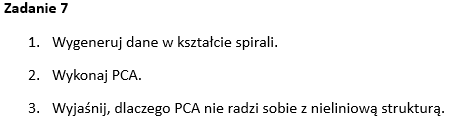

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =========================
# 1. Generowanie danych spiralnych
# =========================
np.random.seed(42)

n = 500
t = np.linspace(0, 4 * np.pi, n)

# spirala 2D
x = t * np.cos(t)
y = t * np.sin(t)

X = np.column_stack([x, y])

# opcjonalnie mały szum
noise = np.random.normal(0, 0.3, X.shape)
X_noisy = X + noise

In [38]:
# =========================
# 2. Standaryzacja
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_noisy)

In [39]:
# =========================
# 3. PCA
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Wariancja wyjaśniana przez komponenty:")
for i, v in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {v * 100:.2f}%")

print("\nŁadunki komponentów:")
print(pca.components_)

Wariancja wyjaśniana przez komponenty:
PC1: 56.40%
PC2: 43.60%

Ładunki komponentów:
[[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]


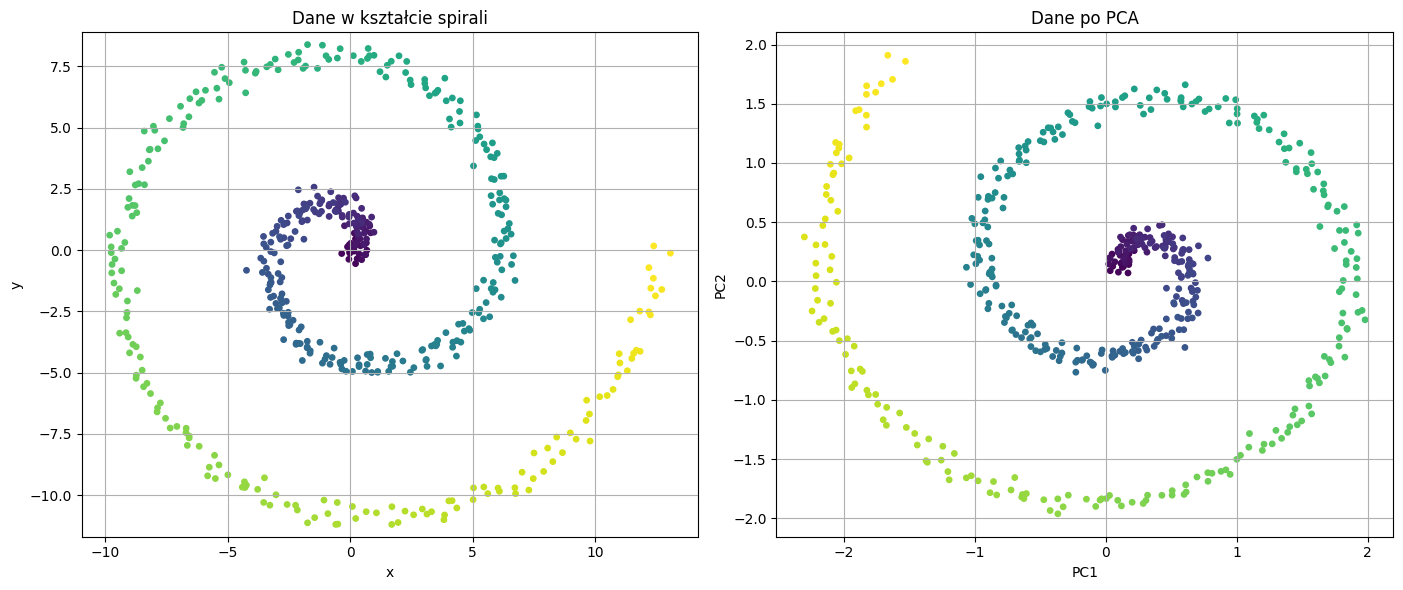

In [40]:
# =========================
# 4. Wizualizacja
# =========================
plt.figure(figsize=(14, 6))

# Oryginalna spirala
plt.subplot(1, 2, 1)
plt.scatter(X_noisy[:, 0], X_noisy[:, 1], c=t, s=15)
plt.title("Dane w kształcie spirali")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)

# Dane po PCA
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=t, s=15)
plt.title("Dane po PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)

plt.tight_layout()
plt.show()

### Zadanie 8
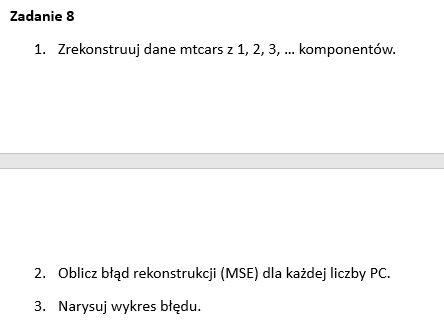

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# =========================
# 1. Dane (mtcars)
# =========================
# Jeśli masz seaborn:
import seaborn as sns
df = sns.load_dataset("mpg").dropna()  # mtcars nie ma w sklearn, mpg jako zamiennik

# tylko numeryczne kolumny
df = df.select_dtypes(include=[np.number])

X = df.values
n_features = X.shape[1]

In [42]:
# =========================
# 2. Standaryzacja
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [43]:
# =========================
# 3. PCA + rekonstrukcja
# =========================
mse_list = []

components_range = range(1, n_features + 1)

for k in components_range:
    pca = PCA(n_components=k)
    X_pca = pca.fit_transform(X_scaled)
    
    # rekonstrukcja
    X_reconstructed_scaled = pca.inverse_transform(X_pca)
    
    # błąd w przestrzeni standaryzowanej
    mse = mean_squared_error(X_scaled, X_reconstructed_scaled)
    mse_list.append(mse)

In [44]:
# =========================
# 4. Wyniki tabelaryczne
# =========================
results = pd.DataFrame({
    "Liczba komponentów": list(components_range),
    "MSE": mse_list
})

print(results)

   Liczba komponentów           MSE
0                   1  2.841949e-01
1                   2  1.605390e-01
2                   3  5.648272e-02
3                   4  3.020913e-02
4                   5  1.279251e-02
5                   6  5.041490e-03
6                   7  1.309362e-31


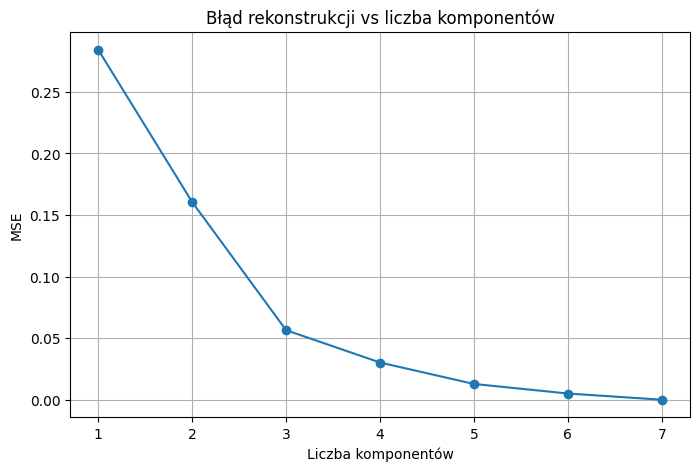

In [45]:
# =========================
# 5. Wykres błędu
# =========================
plt.figure(figsize=(8, 5))
plt.plot(components_range, mse_list, marker='o')

plt.title("Błąd rekonstrukcji vs liczba komponentów")
plt.xlabel("Liczba komponentów")
plt.ylabel("MSE")
plt.grid(True)

plt.show()

### Zadanie 9
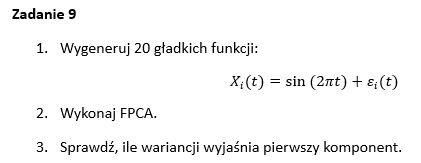

In [46]:
import numpy as np
import matplotlib.pyplot as plt

from skfda import FDataGrid
from skfda.preprocessing.dim_reduction import FPCA

# =========================
# 1. Generowanie 20 gładkich funkcji
# =========================
np.random.seed(42)

n_functions = 20
n_grid = 200
t = np.linspace(0, 1, n_grid)

functions = []

for i in range(n_functions):
    # gładki szum: kilka harmonicznych o małej amplitudzie
    a1 = np.random.normal(0, 0.08)
    a2 = np.random.normal(0, 0.05)
    a3 = np.random.normal(0, 0.03)

    smooth_noise = (
        a1 * np.sin(2 * np.pi * t)
        + a2 * np.cos(4 * np.pi * t)
        + a3 * np.sin(6 * np.pi * t)
    )

    x_i = np.sin(2 * np.pi * t) + smooth_noise
    functions.append(x_i)

X = np.array(functions)

In [47]:
# =========================
# 2. Obiekt danych funkcyjnych
# =========================
fd = FDataGrid(data_matrix=X, grid_points=t)

In [48]:
# =========================
# 3. FPCA
# =========================
fpca = FPCA(n_components=5)
fpca.fit(fd)

explained_variance_ratio = fpca.explained_variance_ratio_

print("Wariancja wyjaśniana przez kolejne komponenty:")
for i, var in enumerate(explained_variance_ratio, start=1):
    print(f"FPC{i}: {100 * var:.2f}%")

print(f"\nPierwszy komponent wyjaśnia: {100 * explained_variance_ratio[0]:.2f}% wariancji")

Wariancja wyjaśniana przez kolejne komponenty:
FPC1: 51.64%
FPC2: 37.37%
FPC3: 10.99%
FPC4: 0.00%
FPC5: 0.00%

Pierwszy komponent wyjaśnia: 51.64% wariancji


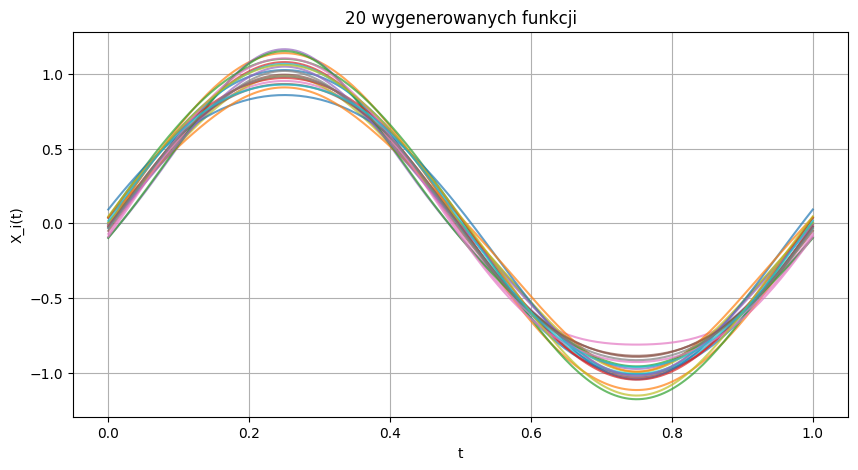

In [50]:
# =========================
# 4. Wizualizacja funkcji
# =========================
plt.figure(figsize=(10, 5))
for i in range(n_functions):
    plt.plot(t, X[i], alpha=0.7)
plt.title("20 wygenerowanych funkcji")
plt.xlabel("t")
plt.ylabel("X_i(t)")
plt.grid(True)
plt.show()

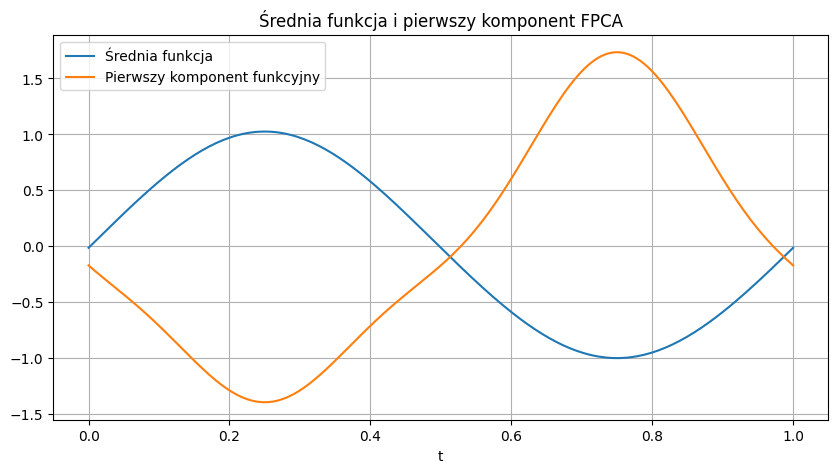

In [51]:
# =========================
# 5. Średnia funkcja + pierwszy komponent
# =========================
mean_function = fd.mean().data_matrix[0, :, 0]
first_component = fpca.components_.data_matrix[0, :, 0]

plt.figure(figsize=(10, 5))
plt.plot(t, mean_function, label="Średnia funkcja")
plt.plot(t, first_component, label="Pierwszy komponent funkcyjny")
plt.title("Średnia funkcja i pierwszy komponent FPCA")
plt.xlabel("t")
plt.grid(True)
plt.legend()
plt.show()

### Zadanie 10
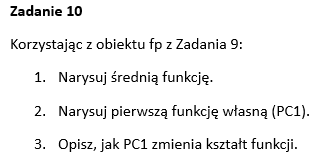

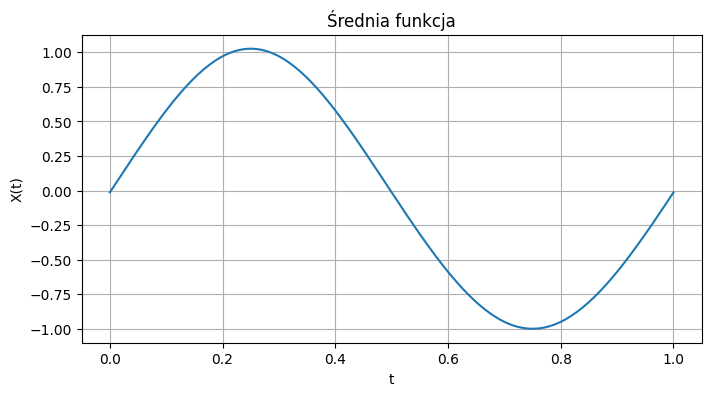

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. Średnia funkcja
# =========================
mean_function = fd.mean().data_matrix[0, :, 0]
t = fd.grid_points[0]

plt.figure(figsize=(8, 4))
plt.plot(t, mean_function)
plt.title("Średnia funkcja")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid(True)
plt.show()

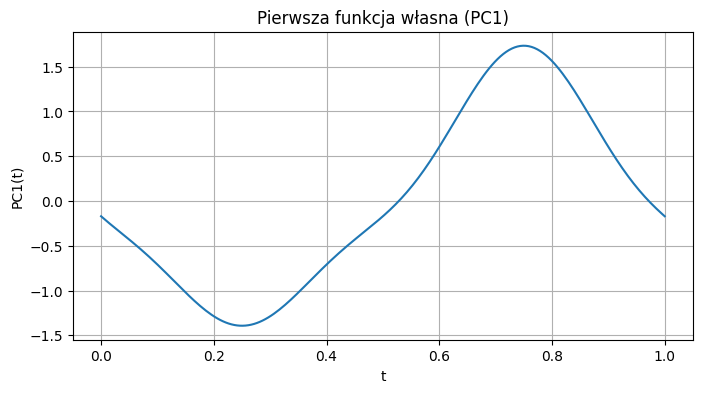

In [53]:
# =========================
# 2. Pierwsza funkcja własna (PC1)
# =========================
pc1 = fpca.components_.data_matrix[0, :, 0]

plt.figure(figsize=(8, 4))
plt.plot(t, pc1)
plt.title("Pierwsza funkcja własna (PC1)")
plt.xlabel("t")
plt.ylabel("PC1(t)")
plt.grid(True)
plt.show()

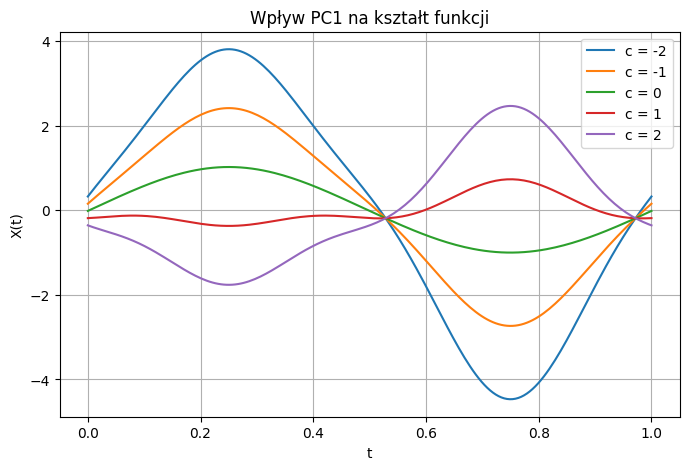

In [54]:
# =========================
# 3. Jak PC1 zmienia funkcję (wizualizacja)
# =========================
# pokazujemy mean +/- c * PC1

c_values = [-2, -1, 0, 1, 2]

plt.figure(figsize=(8, 5))

for c in c_values:
    variation = mean_function + c * pc1
    plt.plot(t, variation, label=f"c = {c}")

plt.title("Wpływ PC1 na kształt funkcji")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.legend()
plt.grid(True)
plt.show()

### Zadanie 11
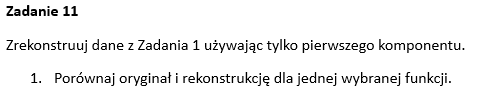

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Średnia funkcja i PC1
# =========================
t = fd.grid_points[0]
mean_function = fd.mean().data_matrix[0, :, 0]
pc1 = fpca.components_.data_matrix[0, :, 0]

In [56]:
# =========================
# 2. Scores funkcji
# =========================
scores = fpca.transform(fd)

# bierzemy jedną wybraną funkcję, np. pierwszą
i = 0

original_function = fd.data_matrix[i, :, 0]

In [57]:
# =========================
# 3. Rekonstrukcja tylko z PC1
# =========================
reconstructed_function = mean_function + scores[i, 0] * pc1

In [58]:
# =========================
# 4. Błąd rekonstrukcji
# =========================
mse = np.mean((original_function - reconstructed_function) ** 2)
rmse = np.sqrt(mse)

print(f"Indeks funkcji: {i}")
print(f"MSE rekonstrukcji z 1 komponentu: {mse:.6f}")
print(f"RMSE rekonstrukcji z 1 komponentu: {rmse:.6f}")

Indeks funkcji: 0
MSE rekonstrukcji z 1 komponentu: 0.000485
RMSE rekonstrukcji z 1 komponentu: 0.022022


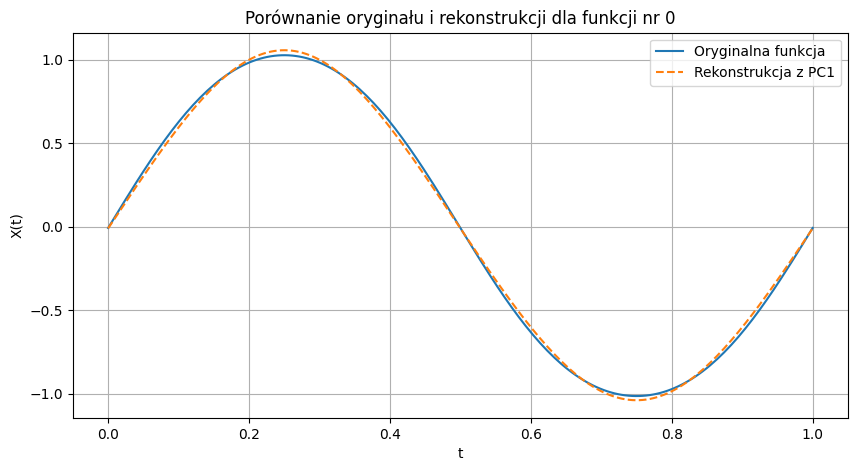

In [59]:
# =========================
# 5. Wykres porównawczy
# =========================
plt.figure(figsize=(10, 5))
plt.plot(t, original_function, label="Oryginalna funkcja")
plt.plot(t, reconstructed_function, label="Rekonstrukcja z PC1", linestyle="--")
plt.title(f"Porównanie oryginału i rekonstrukcji dla funkcji nr {i}")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.legend()
plt.grid(True)
plt.show()

Kilka funkcji na raz

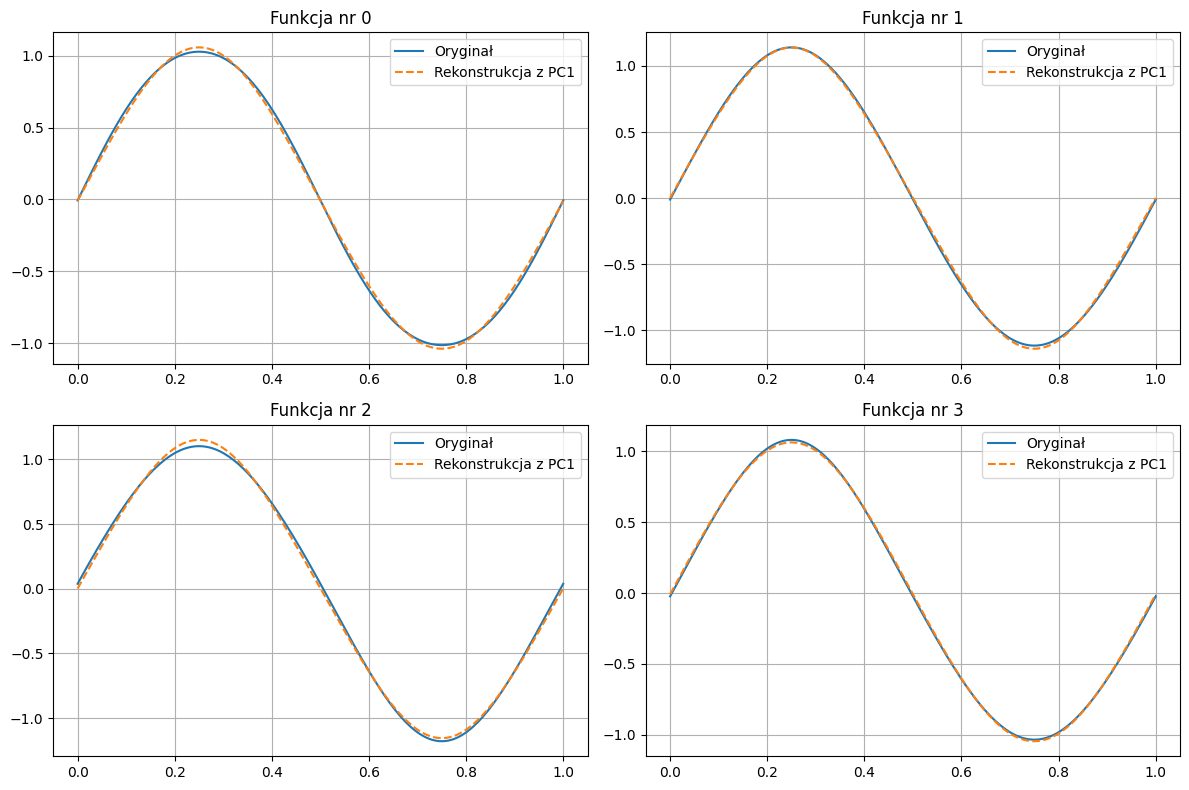

In [60]:
plt.figure(figsize=(12, 8))

for i in range(4):
    original_function = fd.data_matrix[i, :, 0]
    reconstructed_function = mean_function + scores[i, 0] * pc1

    plt.subplot(2, 2, i + 1)
    plt.plot(t, original_function, label="Oryginał")
    plt.plot(t, reconstructed_function, "--", label="Rekonstrukcja z PC1")
    plt.title(f"Funkcja nr {i}")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

### Zadanie 12
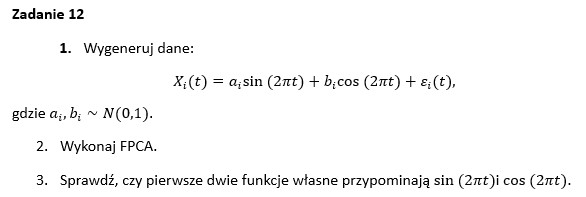

In [61]:
import numpy as np
import matplotlib.pyplot as plt

from skfda import FDataGrid
from skfda.preprocessing.dim_reduction import FPCA

# =========================
# 1. Generowanie danych
# =========================
np.random.seed(42)

n_functions = 100
n_grid = 300
t = np.linspace(0, 1, n_grid)

functions = []

for i in range(n_functions):
    a_i = np.random.normal(0, 1)
    b_i = np.random.normal(0, 1)

    # mały gładki szum
    c_i = np.random.normal(0, 0.1)
    d_i = np.random.normal(0, 0.1)

    eps_i = (
        c_i * np.sin(4 * np.pi * t)
        + d_i * np.cos(6 * np.pi * t)
    )

    x_i = a_i * np.sin(2 * np.pi * t) + b_i * np.cos(2 * np.pi * t) + 0.1 * eps_i
    functions.append(x_i)

X = np.array(functions)

In [62]:
# =========================
# 2. Obiekt funkcyjny
# =========================
fd = FDataGrid(data_matrix=X, grid_points=t)

In [63]:
# =========================
# 3. FPCA
# =========================
fpca = FPCA(n_components=4)
fpca.fit(fd)

explained = fpca.explained_variance_ratio_

print("Wariancja wyjaśniana przez komponenty:")
for i, v in enumerate(explained, start=1):
    print(f"FPC{i}: {100*v:.2f}%")

Wariancja wyjaśniana przez komponenty:
FPC1: 54.68%
FPC2: 45.31%
FPC3: 0.01%
FPC4: 0.01%


In [64]:
# =========================
# 4. Średnia funkcja i komponenty
# =========================
mean_function = fd.mean().data_matrix[0, :, 0]
pc1 = fpca.components_.data_matrix[0, :, 0]
pc2 = fpca.components_.data_matrix[1, :, 0]

# funkcje referencyjne
sin_ref = np.sin(2 * np.pi * t)
cos_ref = np.cos(2 * np.pi * t)

In [66]:
# =========================
# 5. Normalizacja do porównań wizualnych
# =========================
def normalize(f):
    norm = np.sqrt(np.trapezoid(f**2, t))
    if norm == 0:
        return f
    return f / norm

pc1_n = normalize(pc1)
pc2_n = normalize(pc2)
sin_n = normalize(sin_ref)
cos_n = normalize(cos_ref)

In [67]:
# =========================
# 6. Korelacje z sin/cos
# =========================
corr_pc1_sin = np.corrcoef(pc1_n, sin_n)[0, 1]
corr_pc1_cos = np.corrcoef(pc1_n, cos_n)[0, 1]
corr_pc2_sin = np.corrcoef(pc2_n, sin_n)[0, 1]
corr_pc2_cos = np.corrcoef(pc2_n, cos_n)[0, 1]

print("\nKorelacje komponentów z funkcjami referencyjnymi:")
print(f"corr(PC1, sin) = {corr_pc1_sin:.4f}")
print(f"corr(PC1, cos) = {corr_pc1_cos:.4f}")
print(f"corr(PC2, sin) = {corr_pc2_sin:.4f}")
print(f"corr(PC2, cos) = {corr_pc2_cos:.4f}")


Korelacje komponentów z funkcjami referencyjnymi:
corr(PC1, sin) = -0.0871
corr(PC1, cos) = 0.9962
corr(PC2, sin) = 0.9961
corr(PC2, cos) = 0.0877


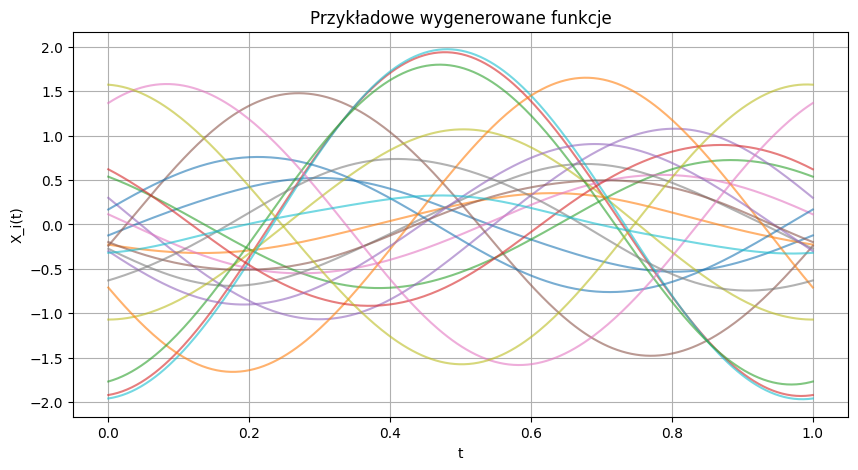

In [68]:
# =========================
# 7. Wizualizacja danych
# =========================
plt.figure(figsize=(10, 5))
for i in range(min(20, n_functions)):
    plt.plot(t, X[i], alpha=0.6)
plt.title("Przykładowe wygenerowane funkcje")
plt.xlabel("t")
plt.ylabel("X_i(t)")
plt.grid(True)
plt.show()

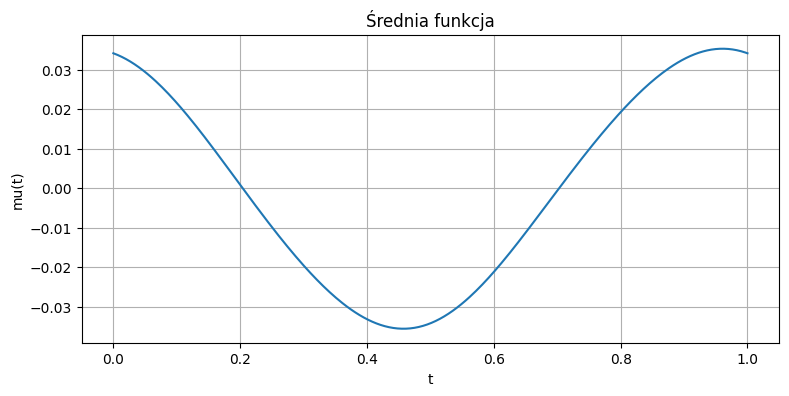

In [69]:
# =========================
# 8. Średnia funkcja
# =========================
plt.figure(figsize=(9, 4))
plt.plot(t, mean_function)
plt.title("Średnia funkcja")
plt.xlabel("t")
plt.ylabel("mu(t)")
plt.grid(True)
plt.show()

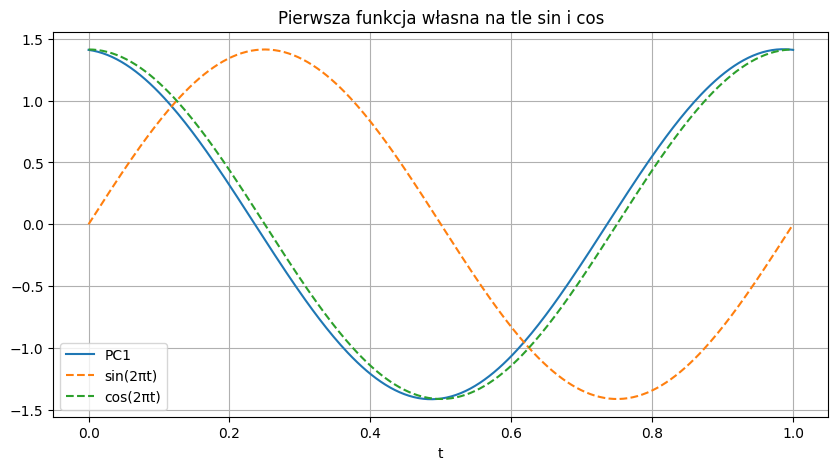

In [70]:
# =========================
# 9. PC1 i porównanie z sin/cos
# =========================
plt.figure(figsize=(10, 5))
plt.plot(t, pc1_n, label="PC1")
plt.plot(t, sin_n, "--", label="sin(2πt)")
plt.plot(t, cos_n, "--", label="cos(2πt)")
plt.title("Pierwsza funkcja własna na tle sin i cos")
plt.xlabel("t")
plt.grid(True)
plt.legend()
plt.show()

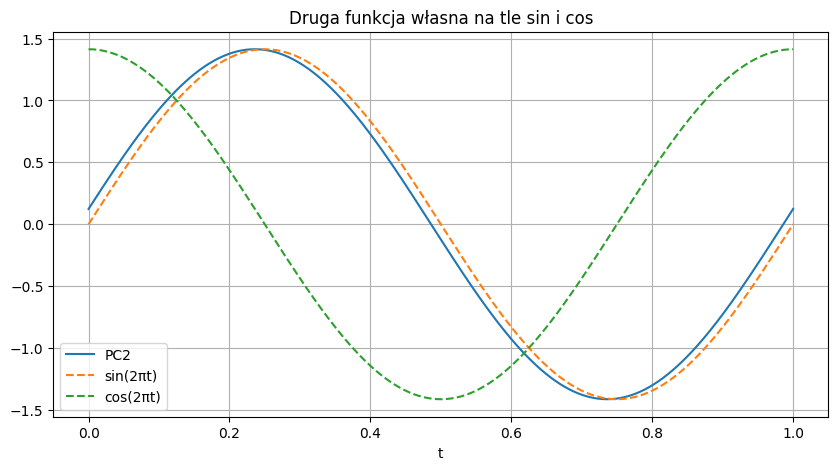

In [71]:
# =========================
# 10. PC2 i porównanie z sin/cos
# =========================
plt.figure(figsize=(10, 5))
plt.plot(t, pc2_n, label="PC2")
plt.plot(t, sin_n, "--", label="sin(2πt)")
plt.plot(t, cos_n, "--", label="cos(2πt)")
plt.title("Druga funkcja własna na tle sin i cos")
plt.xlabel("t")
plt.grid(True)
plt.legend()
plt.show()

### Zadanie 13
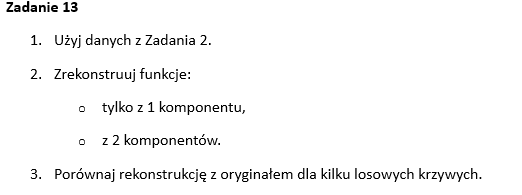

In [72]:
import numpy as np
import matplotlib.pyplot as plt

from skfda import FDataGrid
from skfda.preprocessing.dim_reduction import FPCA

# =========================
# 1. Generowanie danych z Zadania 12
# =========================
np.random.seed(42)

n_functions = 100
n_grid = 300
t = np.linspace(0, 1, n_grid)

functions = []

for i in range(n_functions):
    a_i = np.random.normal(0, 1)
    b_i = np.random.normal(0, 1)

    c_i = np.random.normal(0, 0.1)
    d_i = np.random.normal(0, 0.1)

    eps_i = c_i * np.sin(4 * np.pi * t) + d_i * np.cos(6 * np.pi * t)

    x_i = a_i * np.sin(2 * np.pi * t) + b_i * np.cos(2 * np.pi * t) + 0.1 * eps_i
    functions.append(x_i)

X = np.array(functions)

In [73]:
# =========================
# 2. Obiekt funkcyjny
# =========================
fd = FDataGrid(data_matrix=X, grid_points=t)

In [74]:
# =========================
# 3. FPCA
# =========================
fpca = FPCA(n_components=5)
fpca.fit(fd)

scores = fpca.transform(fd)
components = fpca.components_.data_matrix[:, :, 0]
mean_function = fd.mean().data_matrix[0, :, 0]

In [75]:
# =========================
# 4. Funkcja rekonstrukcji
# =========================
def reconstruct_function(i, k):
    reconstruction = mean_function.copy()
    for j in range(k):
        reconstruction += scores[i, j] * components[j]
    return reconstruction

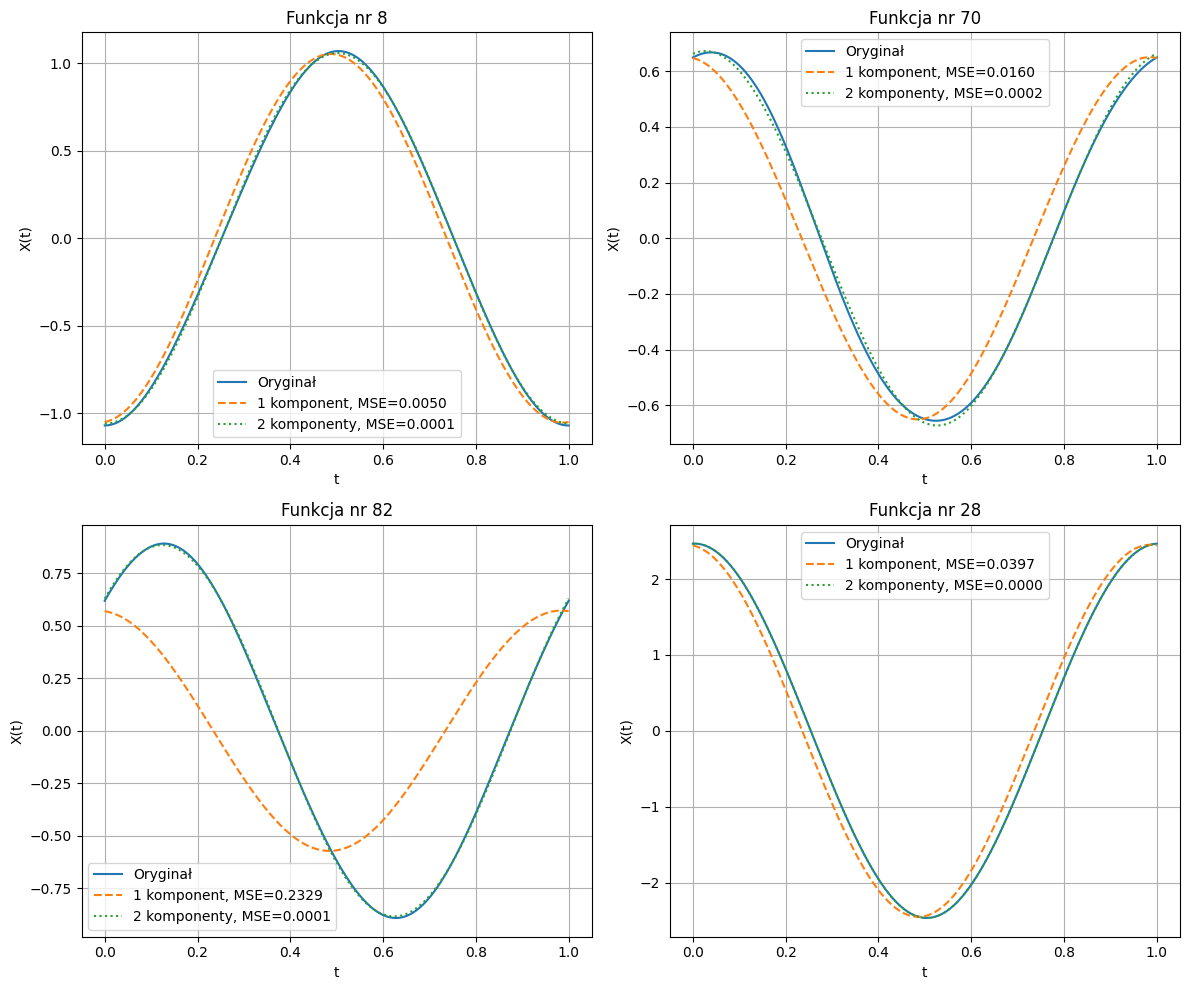

In [76]:
# =========================
# 5. Losowe funkcje do porównania
# =========================
np.random.seed(123)
indices = np.random.choice(n_functions, size=4, replace=False)

plt.figure(figsize=(12, 10))

for plot_idx, i in enumerate(indices, start=1):
    original = X[i]
    recon_1 = reconstruct_function(i, 1)
    recon_2 = reconstruct_function(i, 2)

    mse_1 = np.mean((original - recon_1) ** 2)
    mse_2 = np.mean((original - recon_2) ** 2)

    plt.subplot(2, 2, plot_idx)
    plt.plot(t, original, label="Oryginał")
    plt.plot(t, recon_1, "--", label=f"1 komponent, MSE={mse_1:.4f}")
    plt.plot(t, recon_2, ":", label=f"2 komponenty, MSE={mse_2:.4f}")
    plt.title(f"Funkcja nr {i}")
    plt.xlabel("t")
    plt.ylabel("X(t)")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()